# Intro to Aperiodic Flow Metrics

This notebook introduces **order-flow analytics** with the `aperiodic` Python package.
We focus on a single large-cap instrument — **Binance BTC perpetuals**
(`perpetual-BTC-USDT:USDT`) — over the exact six-month window from **September 1, 2025**
through **February 28, 2026**, using **5-minute** observations.

## Why flow matters

Order-flow metrics try to answer a simple question: **who was more aggressive — buyers or sellers?**
In futures markets, taker flow and cumulative delta are often used as short-horizon pressure gauges,
while trade concentration and toxicity-style metrics help highlight potentially more informed or more urgent activity.

Aperiodic exposes a rich `flow` metric family including taker buy/sell volume, counts, notional delta,
flow entropy, and toxicity-style features.

**Background reading**
- Aperiodic product overview: https://aperiodic.io/
- Binance Academy, makers vs takers: https://www.binance.com/en/academy/articles/what-are-makers-and-takers
- Binance Academy, order books: https://www.binance.com/en/academy/articles/what-is-an-order-book-and-how-does-it-work

In [1]:
from __future__ import annotations

import os
from datetime import date
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv
from dotenv import load_dotenv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE_URL = "https://aperiodic.io/api/v1"
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 9, 1)
END_DATE = date(2026, 2, 28)
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

WORKDIR = Path.cwd().resolve()
ENV_PATH = WORKDIR / ".env"
if not ENV_PATH.exists() and (WORKDIR.parent / ".env").exists():
    ENV_PATH = WORKDIR.parent / ".env"
load_dotenv(ENV_PATH)
API_KEY = os.environ["APERIODIC_API_KEY"]


def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)

def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)



def pct_bps(series: pd.Series) -> pd.Series:
    return series * 10_000

## Fetch BTC OHLCV context and flow metrics

Aperiodic's SDK downloads partitioned aggregates efficiently. We clip the returned frames to the exact
analysis window so the notebook stays on a strict six-month horizon.

In [2]:
price = clip_window(
    get_ohlcv(
        api_key=API_KEY,
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        base_url=BASE_URL,
        output="pandas",
        show_progress=False,
    )
)

flow = clip_window(
    get_metrics(
        api_key=API_KEY,
        metric="flow",
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        base_url=BASE_URL,
        output="pandas",
        show_progress=False,
    )
)

len(price), len(flow)

(52128, 52128)

In [3]:
flow = flow.merge(price[["time", "close", "volume_notional"]], on="time", how="left")
flow["net_delta"] = flow["volume_delta"]
flow["cumulative_delta"] = flow["net_delta"].cumsum()
flow["net_delta_notional_m"] = flow["volume_delta_notional"] / 1_000_000
flow["rolling_net_delta_1d"] = flow["net_delta_notional_m"].rolling(288).sum()
flow["rolling_buy_sell_ratio_1d"] = flow["taker_buy_sell_ratio"].rolling(288).mean()
flow["flow_toxicity_score"] = flow["flow_toxicity_score"].fillna(0)
flow["large_trade_share"] = (
    flow["taker_buy_large_order_count"] + flow["taker_sell_large_order_count"]
) / (flow["taker_buy_count"] + flow["taker_sell_count"])
flow["large_trade_share_1d"] = flow["large_trade_share"].rolling(288).mean()
flow["next_30m_return_bps"] = pct_bps(flow["close"].pct_change(6).shift(-6))
flow["abs_delta_zscore_1d"] = (
    flow["net_delta_notional_m"].abs() - flow["net_delta_notional_m"].rolling(288).mean()
) / flow["net_delta_notional_m"].rolling(288).std()

summary = pd.Series(
    {
        "Rows": len(flow),
        "Start": flow["time"].min(),
        "End": flow["time"].max(),
        "Mean buy/sell ratio": flow["taker_buy_sell_ratio"].mean(),
        "Median toxicity score": flow["flow_toxicity_score"].median(),
        "Average 5m net delta (BTC)": flow["net_delta"].mean(),
        "Average large-trade share": flow["large_trade_share"].mean(),
    }
)
summary

Rows                                        52128
Start                         2025-09-01 00:00:00
End                           2026-02-28 23:55:00
Mean buy/sell ratio                        1.1389
Median toxicity score                     -0.0021
Average 5m net delta (BTC)                -6.3499
Average large-trade share                  0.2654
dtype: object

## First look at the data

In [4]:
flow[[
    "time",
    "close",
    "taker_buy_volume",
    "taker_sell_volume",
    "net_delta",
    "net_delta_notional_m",
    "flow_toxicity_score",
    "large_trade_share",
]].head()

,time,close,taker_buy_volume,taker_sell_volume,net_delta,net_delta_notional_m,flow_toxicity_score,large_trade_share
0,2025-09-01 00:00:00,"108,056.9000",183.6370,291.6120,-107.9750,-11.6756,0.0000,0.2952
1,2025-09-01 00:05:00,"107,953.1000",496.4710,"1,059.9150",-563.4440,-60.8470,-0.5000,0.3393
2,2025-09-01 00:10:00,"107,927.3000",324.0800,225.7590,98.3210,10.6175,-0.4413,0.2999
3,2025-09-01 00:15:00,"107,900.4000",296.4010,405.6390,-109.2380,-11.7847,-0.1139,0.3189
4,2025-09-01 00:20:00,"107,724.1000",309.3580,739.8770,-430.5190,-46.4163,-0.0891,0.3337


## Chart 1 — BTC price over the analysis window

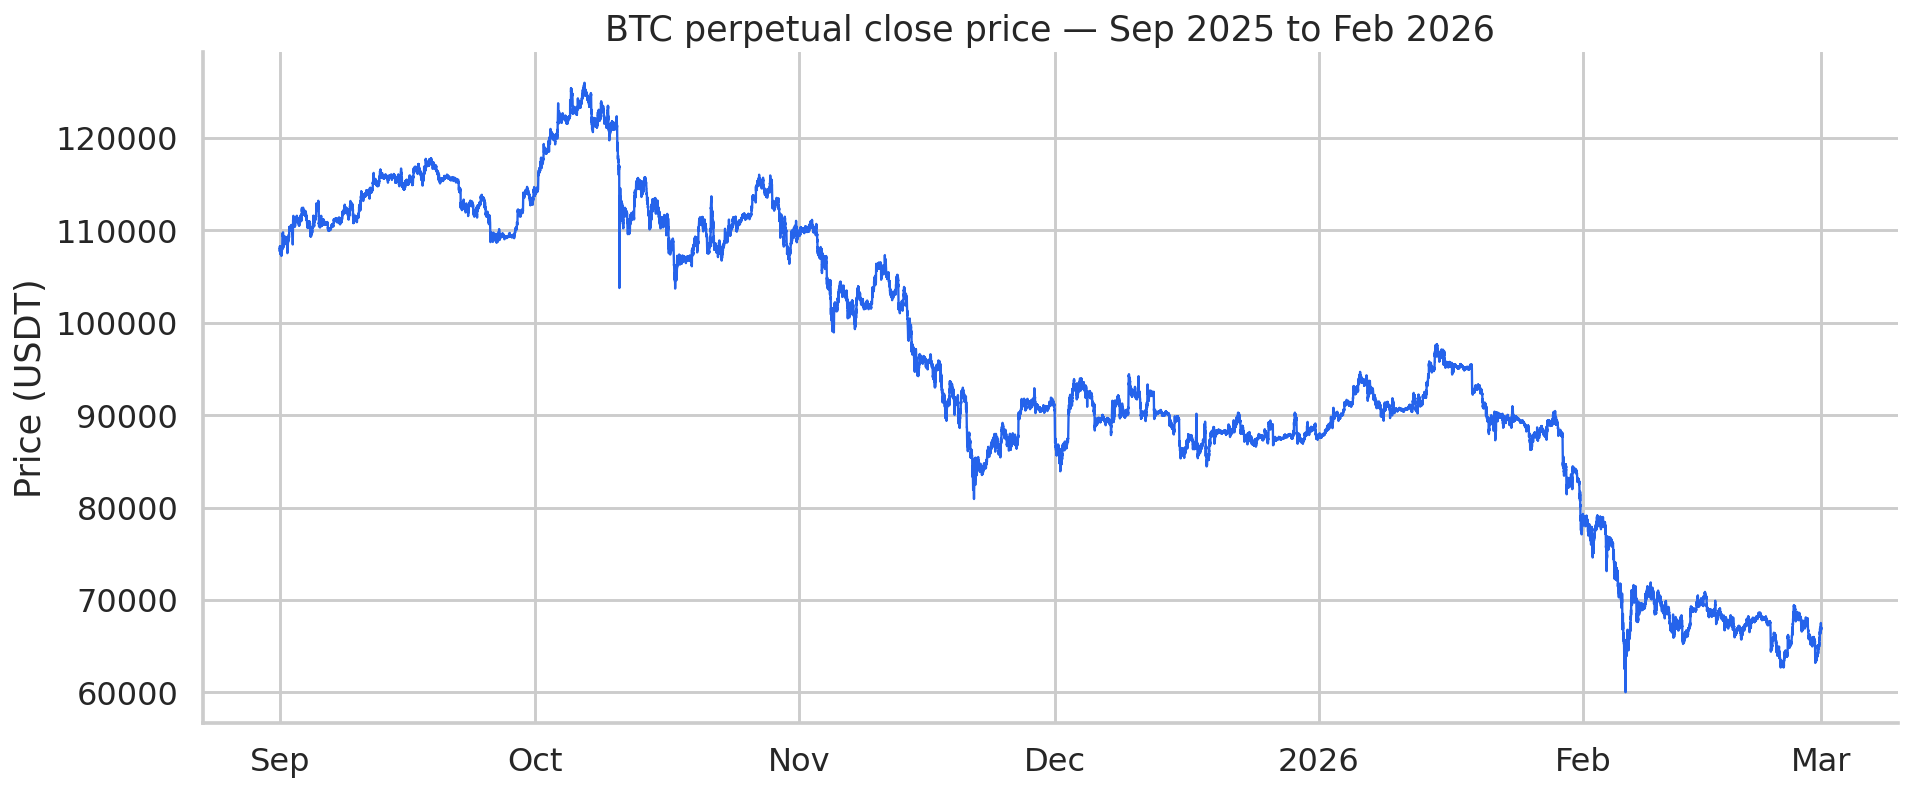

In [5]:
fig, ax = plt.subplots()
ax.plot(price["time"], price["close"], color="#2563eb", linewidth=1.2)
ax.set_title("BTC perpetual close price — Sep 2025 to Feb 2026")
ax.set_ylabel("Price (USDT)")
ax.set_xlabel("")
format_time_axis(ax)
plt.tight_layout()

## Chart 2 — Taker buy vs taker sell volume

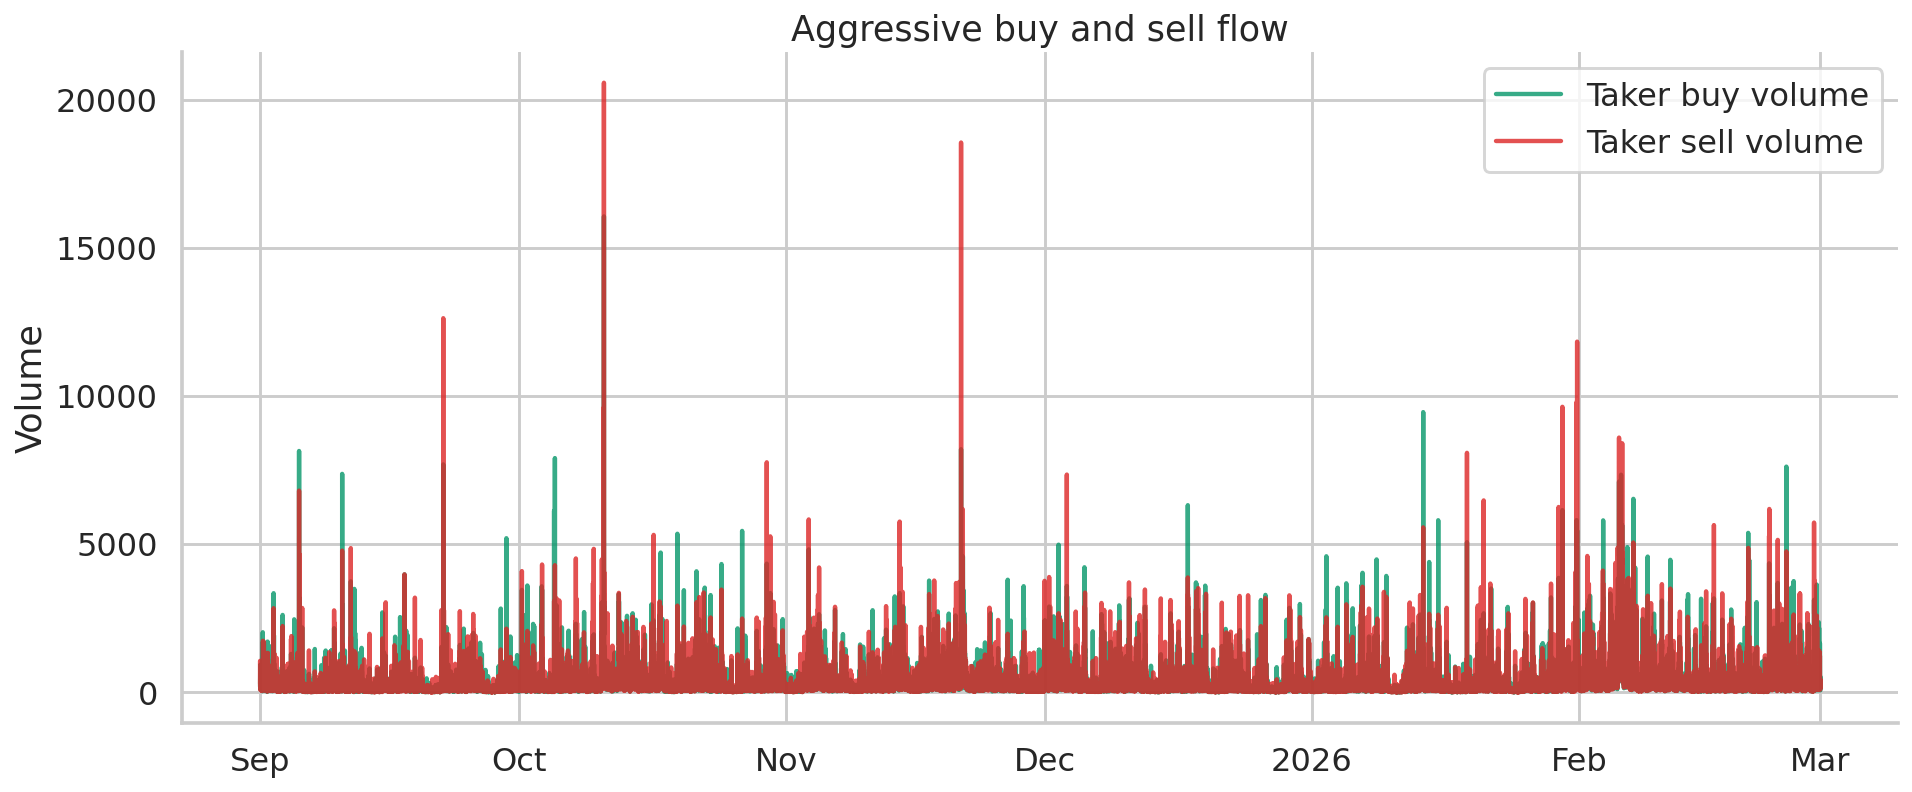

In [6]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["taker_buy_volume"], label="Taker buy volume", color="#059669", alpha=0.8)
ax.plot(flow["time"], flow["taker_sell_volume"], label="Taker sell volume", color="#dc2626", alpha=0.8)
ax.set_title("Aggressive buy and sell flow")
ax.set_ylabel("Volume")
ax.legend(frameon=True)
format_time_axis(ax)
plt.tight_layout()

## Chart 3 — Net delta in notional terms

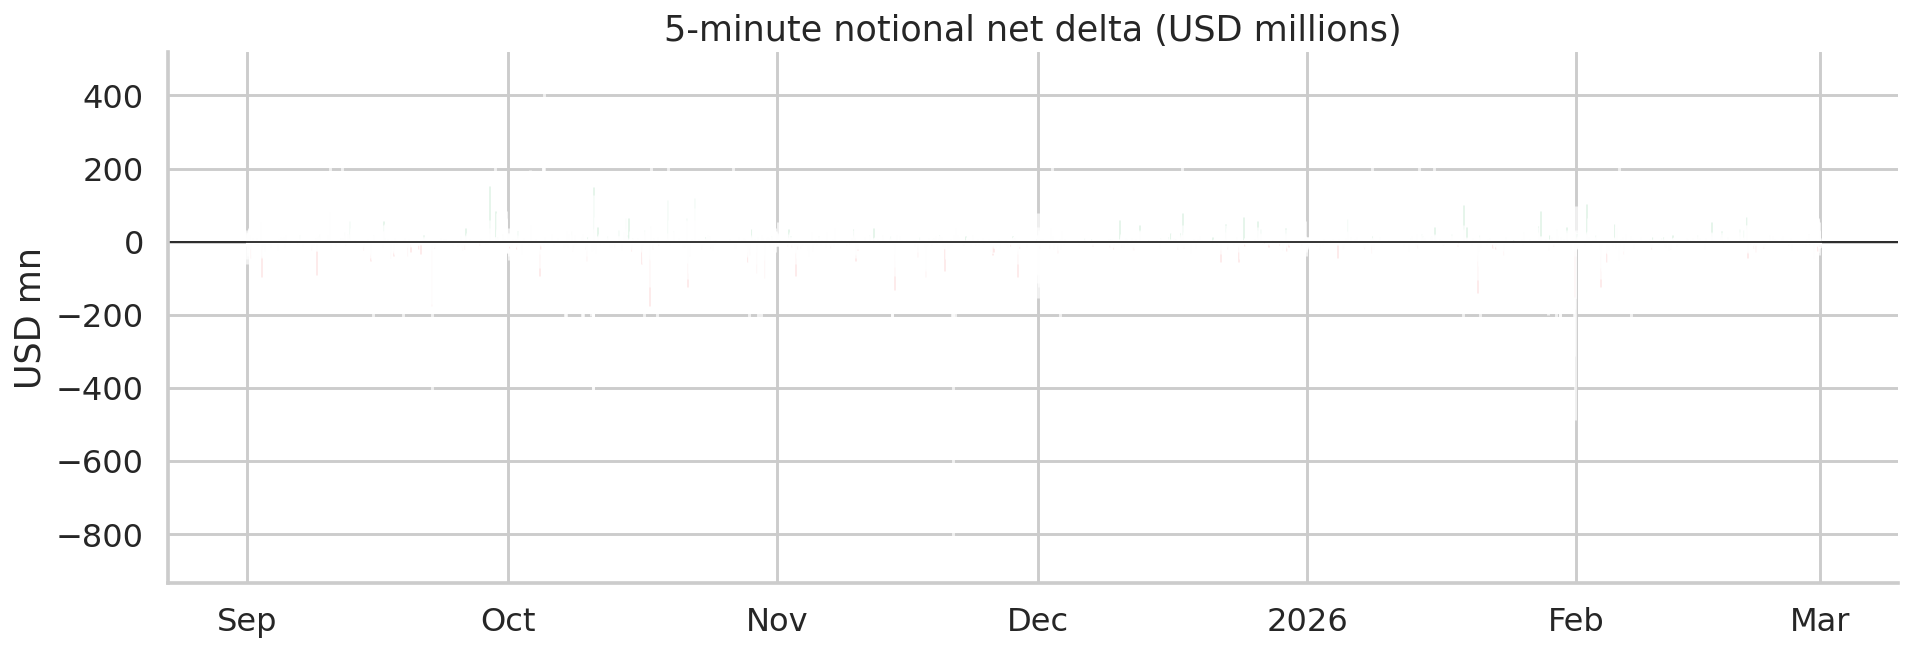

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
up = flow[flow["net_delta_notional_m"] >= 0]
down = flow[flow["net_delta_notional_m"] < 0]
ax.bar(up["time"], up["net_delta_notional_m"], width=0.003, color="#16a34a", alpha=0.7)
ax.bar(down["time"], down["net_delta_notional_m"], width=0.003, color="#ef4444", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("5-minute notional net delta (USD millions)")
ax.set_ylabel("USD mn")
format_time_axis(ax)
plt.tight_layout()

## Chart 4 — Cumulative delta

Cumulative delta summarizes whether aggressive buying or selling dominated over the full sample.

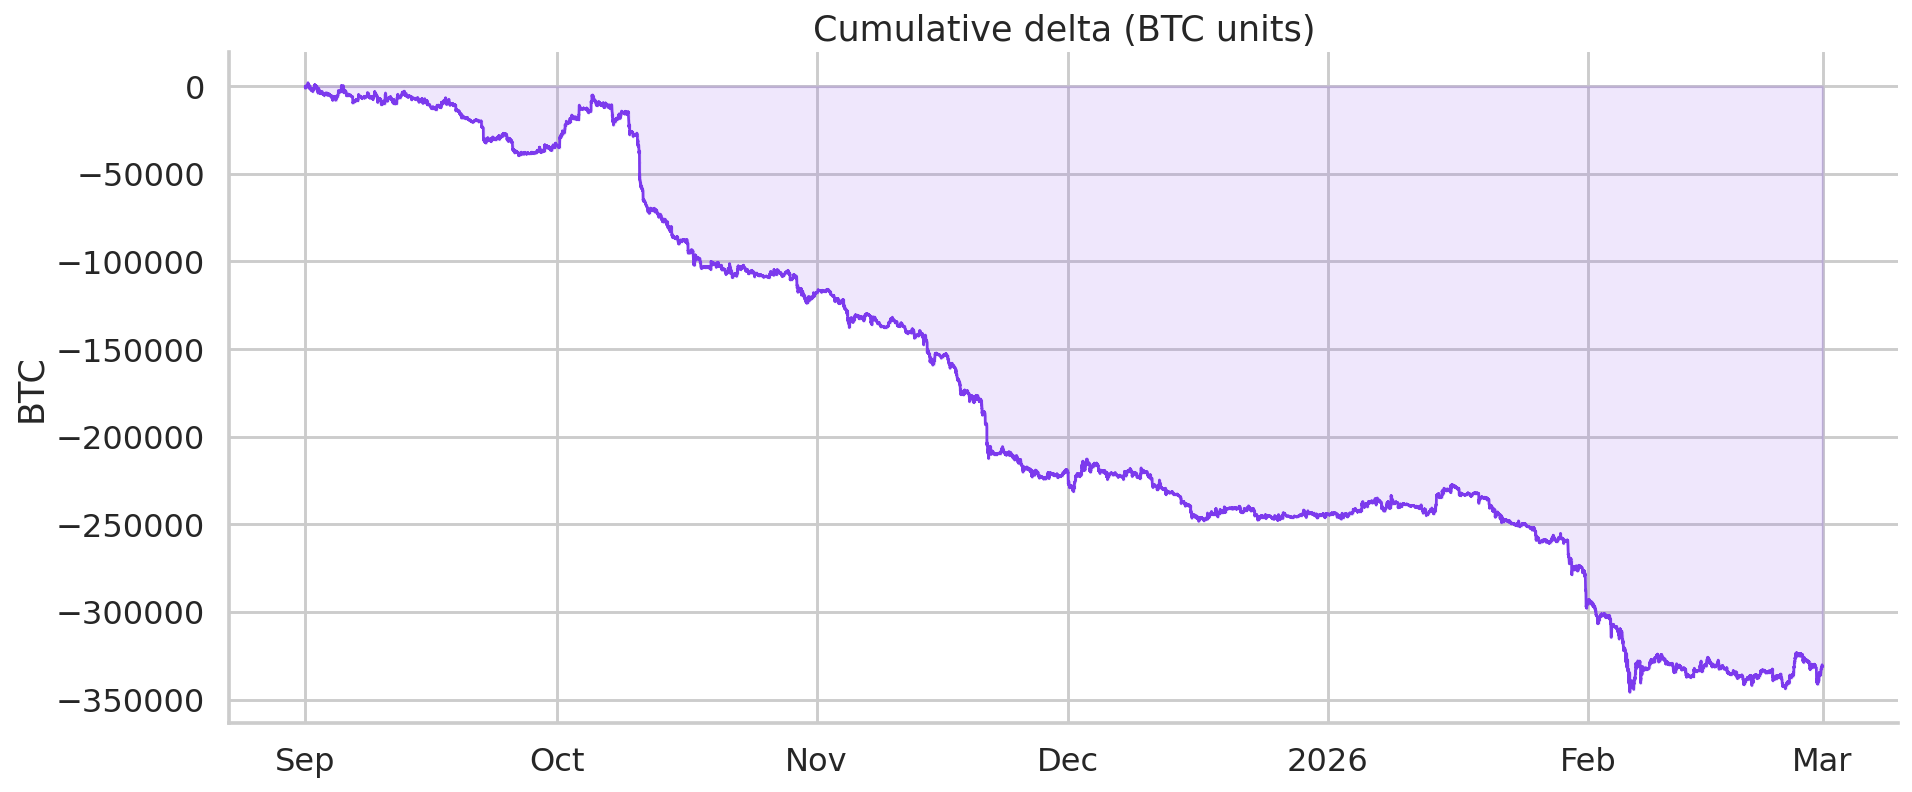

In [8]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["cumulative_delta"], color="#7c3aed", linewidth=1.4)
ax.fill_between(flow["time"], flow["cumulative_delta"], alpha=0.12, color="#7c3aed")
ax.set_title("Cumulative delta (BTC units)")
ax.set_ylabel("BTC")
format_time_axis(ax)
plt.tight_layout()

## Chart 5 — One-day rolling buy/sell ratio

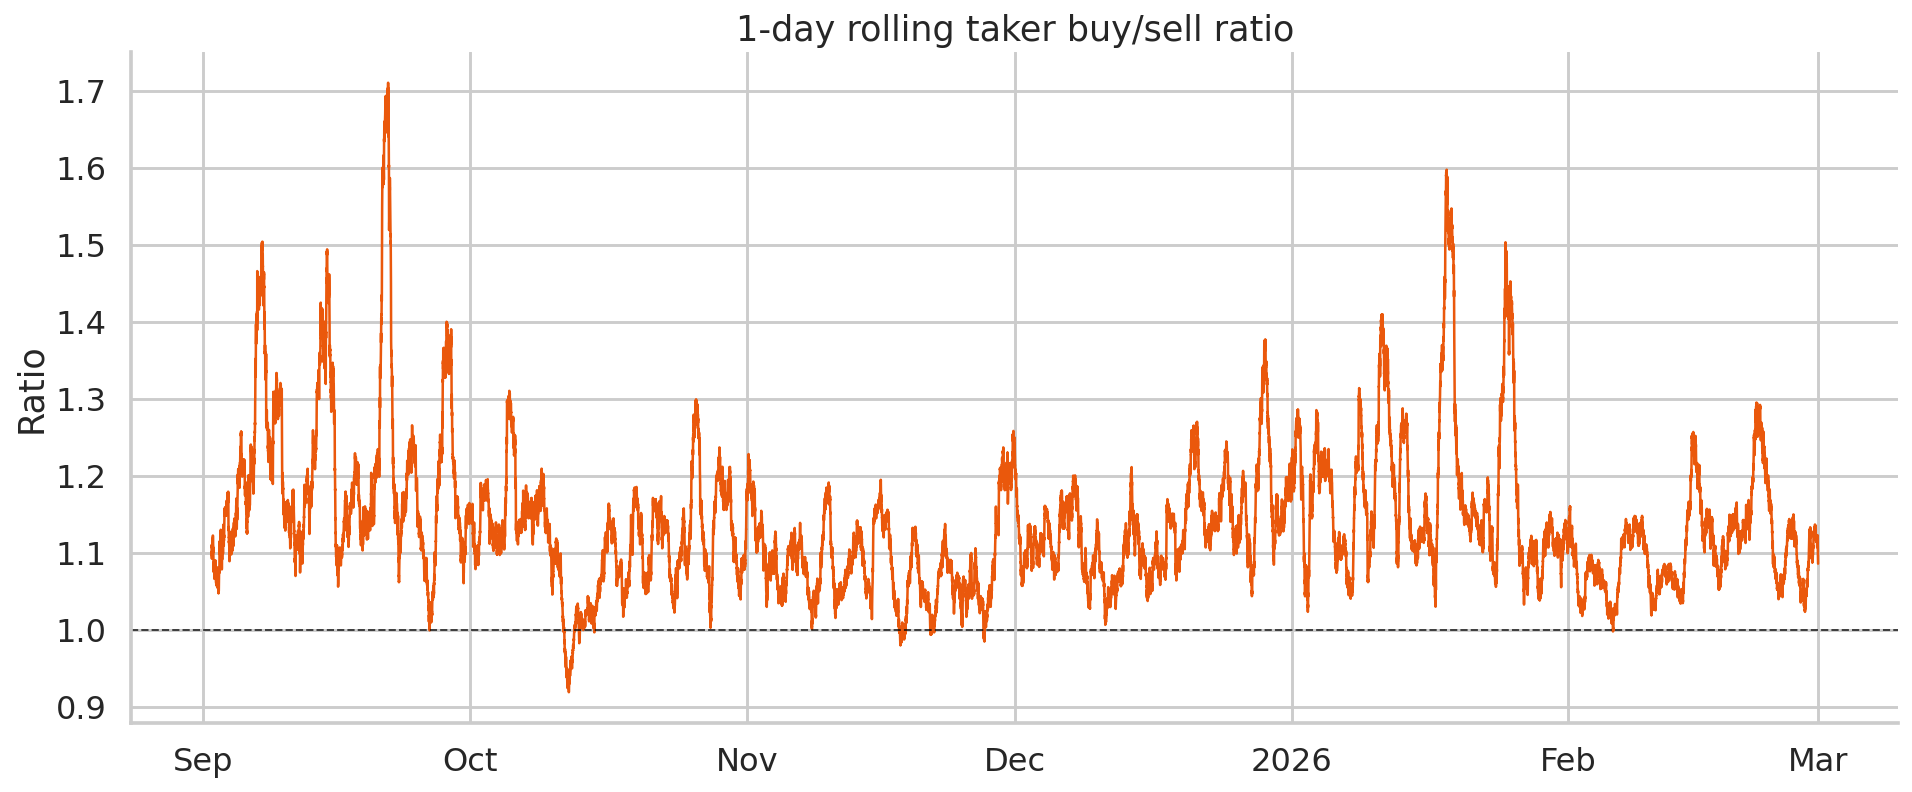

In [9]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["rolling_buy_sell_ratio_1d"], color="#ea580c", linewidth=1.3)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("1-day rolling taker buy/sell ratio")
ax.set_ylabel("Ratio")
format_time_axis(ax)
plt.tight_layout()

## Chart 6 — Flow toxicity score

Higher toxicity-style readings can be interpreted as more one-sided or more adverse selection-prone activity.

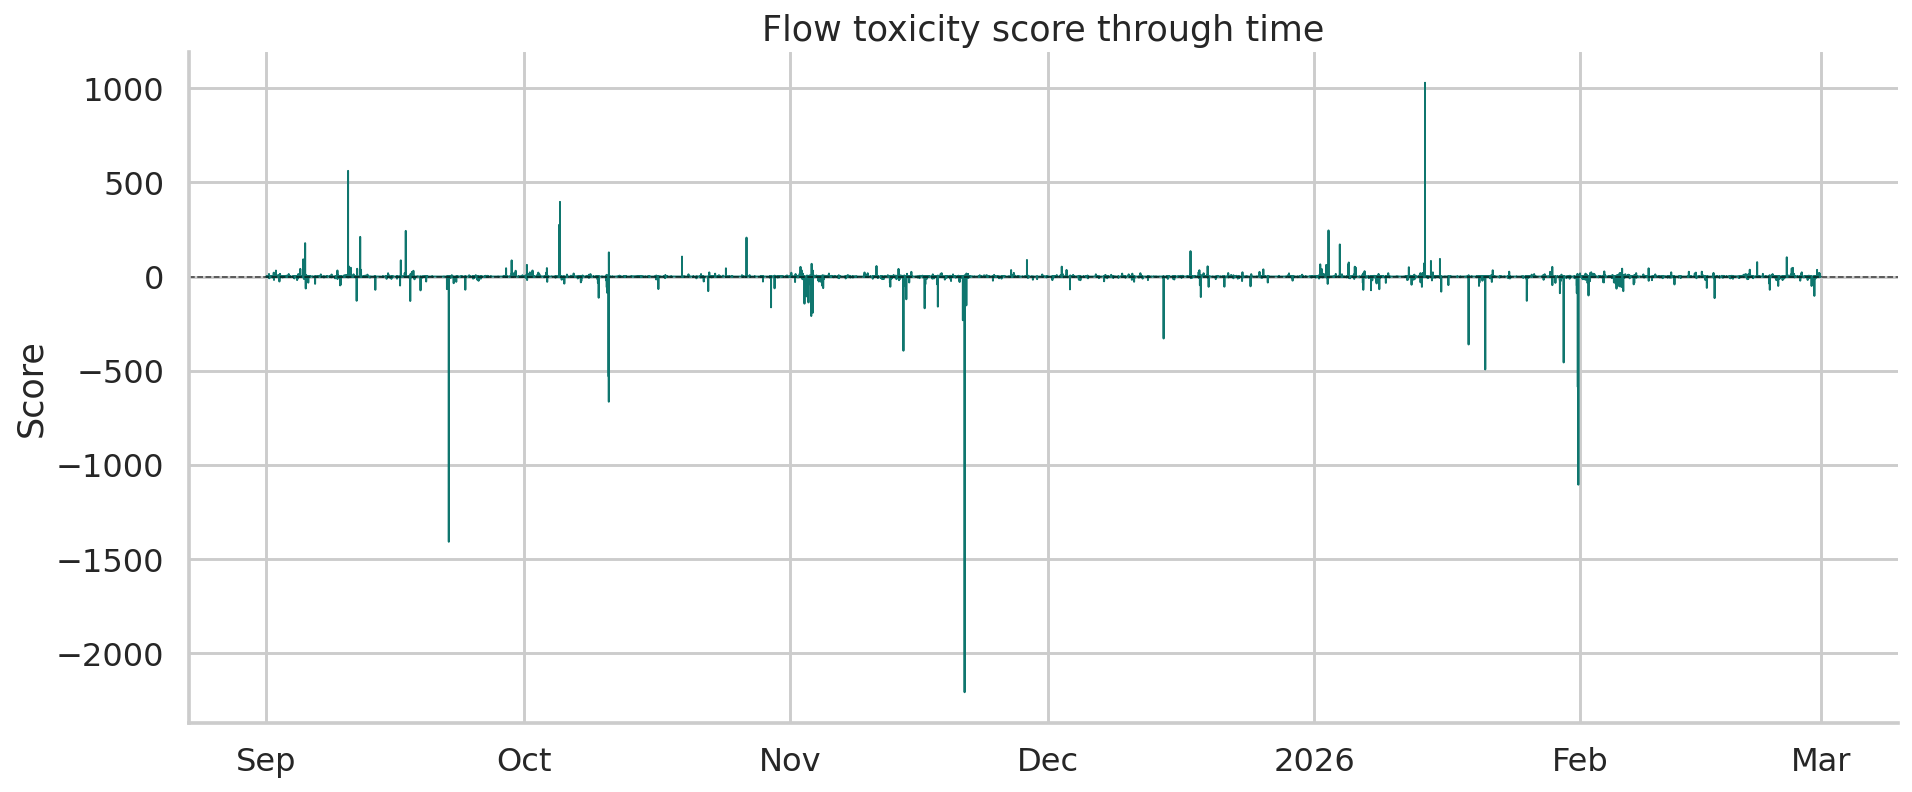

In [10]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["flow_toxicity_score"], color="#0f766e", linewidth=1)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("Flow toxicity score through time")
ax.set_ylabel("Score")
format_time_axis(ax)
plt.tight_layout()

## Chart 7 — Large-trade participation

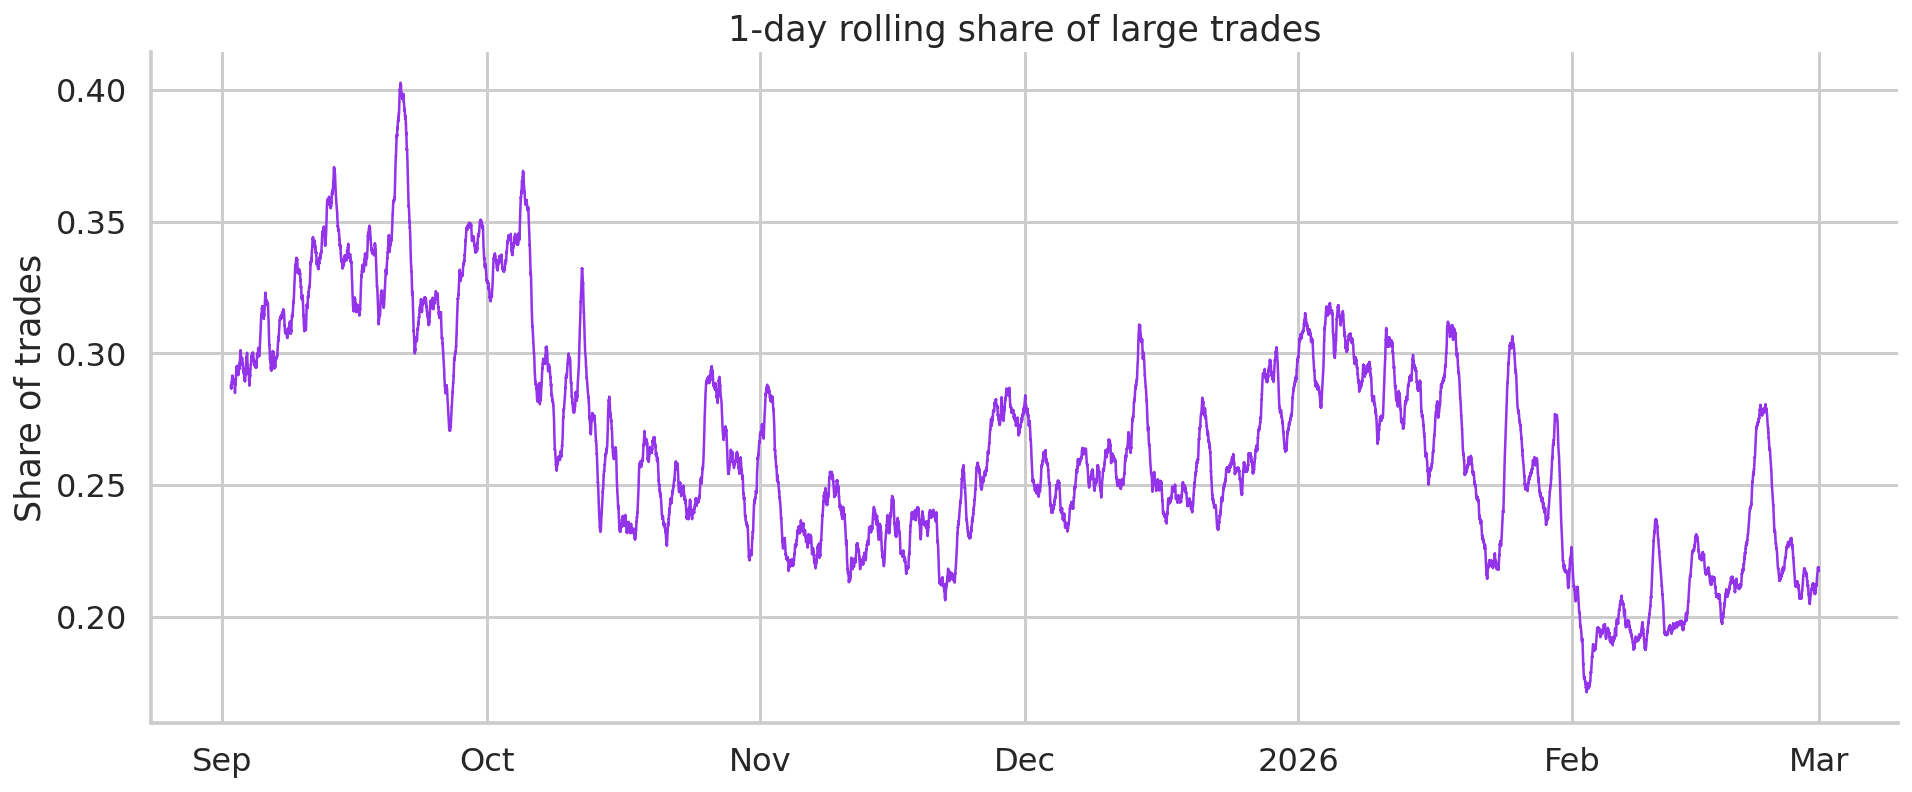

In [11]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["large_trade_share_1d"], color="#9333ea", linewidth=1.3)
ax.set_title("1-day rolling share of large trades")
ax.set_ylabel("Share of trades")
format_time_axis(ax)
plt.tight_layout()

## Chart 8 — Do stretched flow readings line up with future returns?

This is not a predictive model — just a visual check of whether more extreme imbalance tends to coincide with stronger next-30-minute returns.

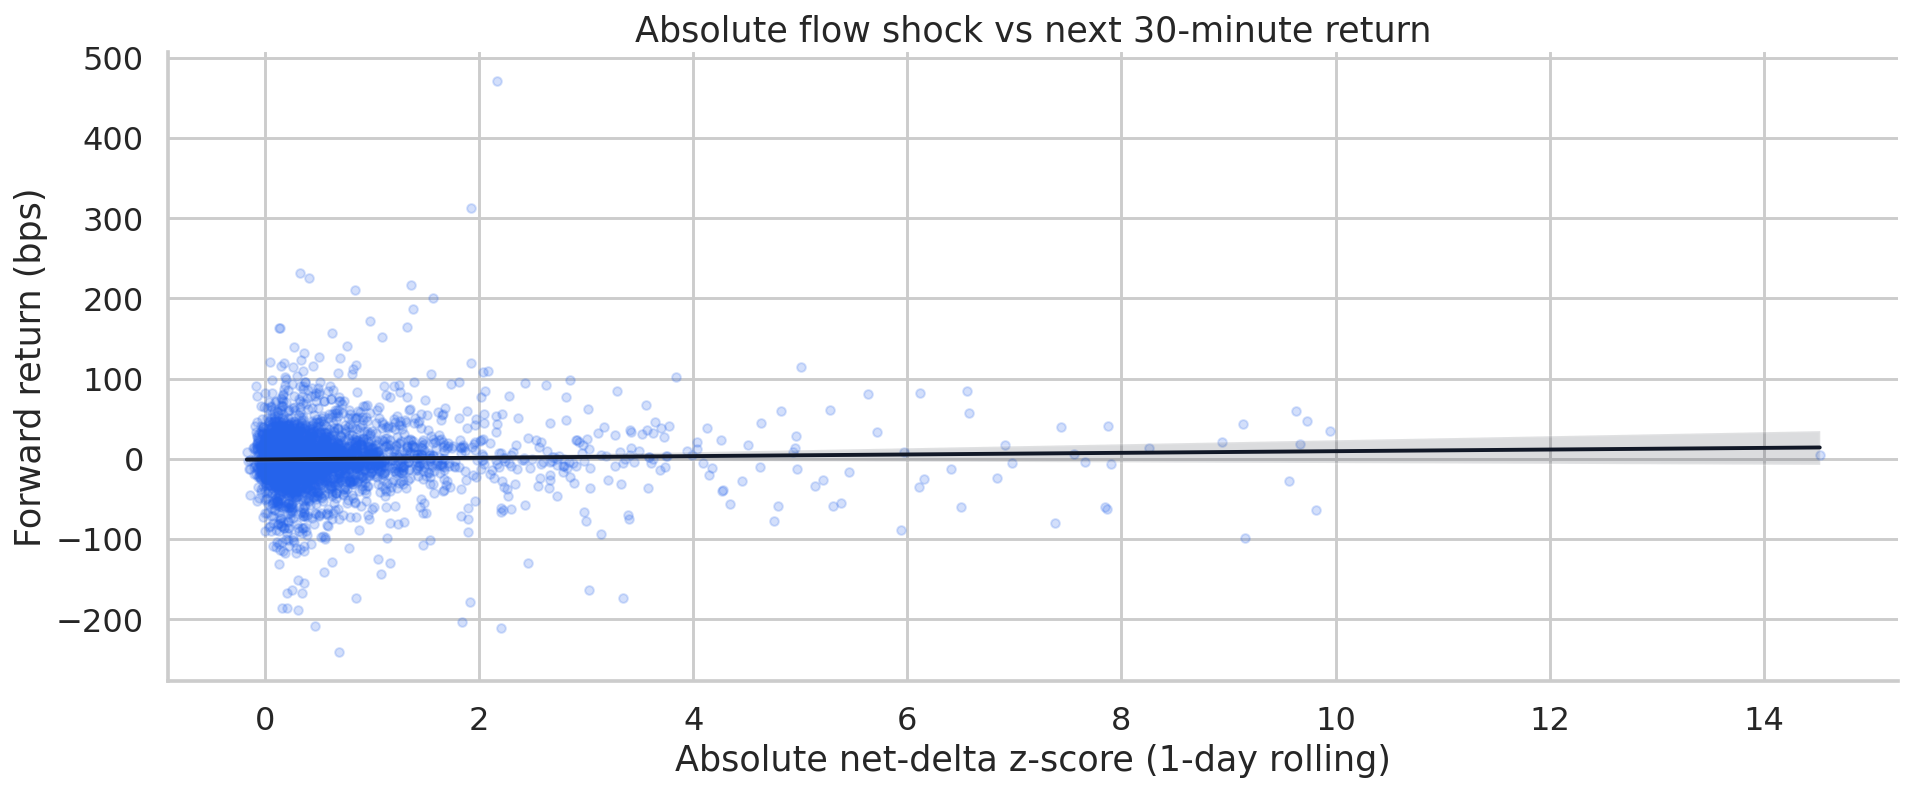

In [12]:
scatter = flow[["abs_delta_zscore_1d", "next_30m_return_bps"]].dropna()
fig, ax = plt.subplots()
sns.regplot(
    data=scatter.sample(min(len(scatter), 4000), random_state=7),
    x="abs_delta_zscore_1d",
    y="next_30m_return_bps",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#2563eb"},
    line_kws={"color": "#111827", "linewidth": 2},
    ax=ax,
)
ax.set_title("Absolute flow shock vs next 30-minute return")
ax.set_xlabel("Absolute net-delta z-score (1-day rolling)")
ax.set_ylabel("Forward return (bps)")
plt.tight_layout()

## Chart 9 — Intraday flow seasonality

The heatmap below highlights which weekday/hour combinations tended to have the strongest average notional imbalance.

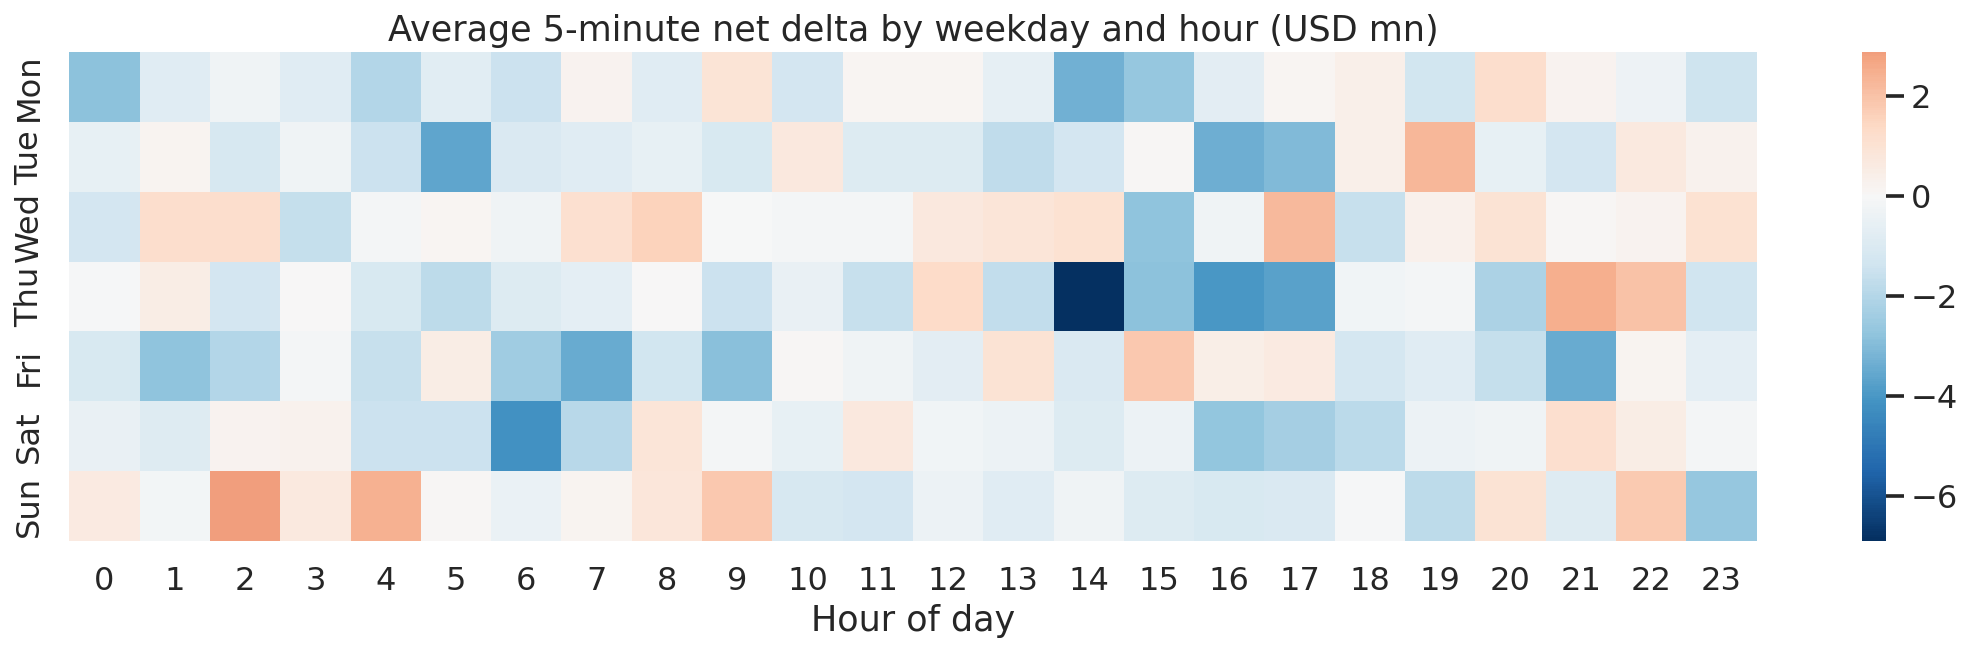

In [13]:
seasonality = flow.assign(
    weekday=flow["time"].dt.day_name().str[:3],
    hour=flow["time"].dt.hour,
).pivot_table(
    index="weekday",
    columns="hour",
    values="net_delta_notional_m",
    aggfunc="mean",
)
seasonality = seasonality.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(seasonality, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Average 5-minute net delta by weekday and hour (USD mn)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()

## A quick event table

In [14]:
flow.nlargest(10, "abs_delta_zscore_1d")[[
    "time",
    "close",
    "net_delta_notional_m",
    "flow_toxicity_score",
    "large_trade_share",
    "next_30m_return_bps",
]].reset_index(drop=True)

,time,close,net_delta_notional_m,flow_toxicity_score,large_trade_share,next_30m_return_bps
0,2025-11-21 07:30:00,"83,342.7000",-866.6526,"-2,206.3567",0.4820,46.5548
1,2025-09-22 06:00:00,"112,439.6000",-556.7658,"-1,407.8762",0.4398,19.7795
2,2025-10-19 09:45:00,"107,895.3000",358.6172,105.8761,0.4112,-37.9813
3,2025-10-26 09:20:00,"112,304.8000",151.1381,7.3344,0.3891,4.7371
4,2025-12-14 11:40:00,"88,829.8000",-170.4962,-328.8503,0.3556,50.5461
5,2025-10-05 02:25:00,"122,821.7000",294.3296,47.1500,0.4349,96.9291
6,2026-01-19 00:00:00,"92,920.5000",-279.5708,-360.6479,0.3907,-45.0385
7,2025-09-22 00:30:00,"114,936.1000",-151.0049,-37.3213,0.3852,-44.4421
8,2025-11-28 13:45:00,"92,282.4000",170.0651,88.0898,0.3612,3.6193
9,2025-12-17 14:50:00,"89,259.2000",215.9994,134.7405,0.3574,49.8324


## Takeaways

- BTC perpetual flow is **highly bursty** at a 5-minute horizon.
- Cumulative delta helps separate short-lived noise from persistent aggressive buying/selling pressure.
- Large-trade participation and toxicity-style features add useful **microstructure context** beyond raw buy/sell volume.
- For practical trading research, flow is usually most useful **alongside price, liquidity, and derivatives positioning** rather than by itself.

## Further reading
- Aperiodic: https://aperiodic.io/
- Makers vs takers: https://www.binance.com/en/academy/articles/what-are-makers-and-takers
- Order books: https://www.binance.com/en/academy/articles/what-is-an-order-book-and-how-does-it-work